# KNN Graph Face Clustering Debug Notebook

This notebook implements a high-precision face clustering pipeline for small batches (10-20 faces) using:
- Quality gating (pose + blur + top-N faces per image)
- Mutual kNN graph with distance threshold
- Connected components clustering
- d10-based exemplar selection
- Optional cluster splitting
- Optional holdout attachment

## How to Run

1. **Edit Config Cell**: Choose data source (existing embeddings OR new images)
2. **Run Stages**: Execute cells sequentially to see each stage's output
3. **Manual Intervention**: Use override cells to manually adjust core set or edges
4. **Visualize**: View distance matrices, graphs, and face grids at each stage

## Data Sources

**Option A: Load existing embeddings** (recommended for testing)
- Use pre-computed embeddings from benchmark results
- Fast, no InsightFace needed

**Option B: Detect from new images**
- Run InsightFace on new images
- Requires: `pip install insightface onnxruntime`

## Setup & Imports

In [55]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import logging
from PIL import Image
import json

# Auto-reload modules for development
%load_ext autoreload
%autoreload 2

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

# Import face_cluster library
from face_cluster import (
    PipelineConfig,
    InsightFaceEmbedder,
    QualityGater,
    KNNGraphBuilder,
    ConnectedComponentsClusterer,
    D10ExemplarSelector,
    ConservativeMerger,
    HoldoutAttacher,
    FaceRecord,
)
from face_cluster.analysis import ClusterSnapshot
from face_cluster.viz import (
    plot_distance_matrix,
    plot_knn_table,
    plot_graph,
    print_cluster_summary,
    show_face_grid,
    show_cluster_faces,
    plot_d10_histogram,
)

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

print("Imports complete")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports complete


## Configuration

**IMPORTANT**: Choose your data source below!

In [56]:
# ========== DATA SOURCE CONFIGURATION ==========

# Option A: Load existing embeddings (RECOMMENDED)
USE_EXISTING_EMBEDDINGS = True
# RESULTS_DIR = Path("../results/face_clustering_benchmark")
RESULTS_DIR = Path("../results/Google_Germany")

# Enable pose estimation for existing embeddings (requires sixdrepnet)
# Install with: pip install sixdrepnet
ESTIMATE_POSE_FROM_CROPS = True  # Set to False to skip pose filtering

# Option B: Detect from new images
# USE_EXISTING_EMBEDDINGS = False
# IMAGE_DIR = Path("../test_data/faces_sample")
# # Or: IMAGE_PATHS = ["path/to/img1.jpg", "path/to/img2.jpg", ...]

# ========== CLUSTERING PARAMETERS ==========

# Core clustering parameters
K = 5                        # Number of nearest neighbors for mutual kNN
DISTANCE_THRESHOLD = 0.35    # Max cosine distance for edge creation
MIN_CLUSTER_SIZE = 2         # Minimum cluster size (mark smaller as noise)

# Quality gating parameters
YAW_MAX = 30.0              # Max absolute yaw angle (degrees)
PITCH_MAX = 25.0            # Max absolute pitch angle (degrees)
ROLL_MAX = 25.0             # Max absolute roll angle (degrees)
BLUR_MIN = 50.0             # Min blur score (Laplacian variance)
MAX_FACES_PER_IMAGE = 3     # Keep top N faces by area per image [new images only]
MIN_FACE_AREA = None        # Optional: minimum face area in pixels [new images only]

# Exemplar selection parameters
D10_K = 3                   # K for d10 computation
EXEMPLARS_D10_THRESHOLD = 0.35  # Max d10 to be exemplar candidate
N_EXEMPLARS_MAX = 10        # Max exemplars per cluster
EXEMPLAR_SUPPRESSION_RADIUS = 0.2  # Min distance between exemplars

# Conservative merge parameters
MERGE_ENABLED = True        # Enable conservative merge stage
MERGE_USE_ADAPTIVE = True   # Use adaptive per-cluster thresholds
MERGE_THRESHOLD_ALPHA = 0.7 # Weight: 70% local + 30% global
MERGE_MARGIN = 0.0          # Margin for "clear best" check (0.0 = disable, default 0.05)
                            # See docs/MERGE_CRITERIA_EXPLAINED.md for details

# Cluster splitting (optional)
SPLIT_ENABLED = False        # Enable cluster splitting safeguard
SPLIT_DIAMETER_THRESHOLD = 0.6   # Max diameter before trying to split
SPLIT_DISTANCE_THRESHOLD = 0.30  # Tighter threshold for internal splitting
SPLIT_K = 3                 # K for internal mutual kNN

# Holdout attachment (optional)
ATTACH_ENABLED = False       # Enable holdout attachment
ATTACH_DISTANCE_THRESHOLD = 0.35  # Max distance to attach
K_ATTACH = 5                # Number of neighbors to check for voting
VOTE_MIN = 3                # Min votes required
MARGIN = 0.1                # Margin between best and second-best cluster
merge_global_percentile = 75

# ========== END CONFIGURATION ==========

config = PipelineConfig(
    K=K,
    distance_threshold=DISTANCE_THRESHOLD,
    min_cluster_size=MIN_CLUSTER_SIZE,
    yaw_max=YAW_MAX,
    pitch_max=PITCH_MAX,
    roll_max=ROLL_MAX,
    blur_min=BLUR_MIN,
    max_faces_per_image_core=MAX_FACES_PER_IMAGE,
    min_face_area=MIN_FACE_AREA,
    d10_k=D10_K,
    exemplars_d10_threshold=EXEMPLARS_D10_THRESHOLD,
    N_exemplars_max=N_EXEMPLARS_MAX,
    exemplar_suppression_radius=EXEMPLAR_SUPPRESSION_RADIUS,
    # Merge parameters
    merge_enabled=MERGE_ENABLED,
    merge_use_adaptive_threshold=MERGE_USE_ADAPTIVE,
    merge_threshold_alpha=MERGE_THRESHOLD_ALPHA,
    merge_margin=MERGE_MARGIN,
    # Split parameters
    split_enabled=SPLIT_ENABLED,
    split_diameter_threshold=SPLIT_DIAMETER_THRESHOLD,
    split_distance_threshold=SPLIT_DISTANCE_THRESHOLD,
    split_K=SPLIT_K,
    # Attach parameters
    attach_enabled=ATTACH_ENABLED,
    attach_distance_threshold=ATTACH_DISTANCE_THRESHOLD,
    K_attach=K_ATTACH,
    vote_min=VOTE_MIN,
    margin=MARGIN,
    merge_global_percentile=merge_global_percentile
)

print("Configuration loaded:")
print(f"  Data source: {'Existing embeddings' if USE_EXISTING_EMBEDDINGS else 'New images'}")
if USE_EXISTING_EMBEDDINGS:
    print(f"  Pose estimation: {'Enabled' if ESTIMATE_POSE_FROM_CROPS else 'Disabled'}")
print(f"  Core clustering: K={config.K}, threshold={config.distance_threshold}, min_size={config.min_cluster_size}")
print(f"  Quality gating: blur_min={config.blur_min}, yaw_max={config.yaw_max}°, pitch_max={config.pitch_max}°, roll_max={config.roll_max}°")
print(f"  Exemplars: d10_k={config.d10_k}, threshold={config.exemplars_d10_threshold}, max={config.N_exemplars_max}")
print(f"  Merge enabled: {config.merge_enabled} (margin={config.merge_margin})")
print(f"  Split enabled: {config.split_enabled}")
print(f"  Attach enabled: {config.attach_enabled}")

Configuration loaded:
  Data source: Existing embeddings
  Pose estimation: Enabled
  Core clustering: K=5, threshold=0.35, min_size=2
  Quality gating: blur_min=50.0, yaw_max=30.0°, pitch_max=25.0°, roll_max=25.0°
  Exemplars: d10_k=3, threshold=0.35, max=10
  Merge enabled: True (margin=0.0)
  Split enabled: False
  Attach enabled: False


## Stage A: Load Embeddings

**Option A**: Load pre-computed embeddings from benchmark results  
**Option B**: Detect faces from new images using InsightFace

In [57]:
import numpy as np
import matplotlib.pyplot as plt


def plot_distance_matrix_heatmap(
    matrix: np.ndarray,
    vmin: float = 0.0,
    vmax: float = 1.0,
    title: str = "Distance Matrix",
    row_labels: list | None = None,
    col_labels: list | None = None,
    precision: int = 2,
    figsize: tuple[float, float] | None = None,
    cmap: str = "RdYlGn_r",
):
    """Plot distance matrix as heatmap with gridlines and cell values.

    Args:
        matrix: 2D distance matrix (n_rows, n_cols).
        vmin: Color scale lower bound (default 0).
        vmax: Color scale upper bound (default 1).
        title: Plot title.
        row_labels: Optional labels for rows (default 0..n-1).
        col_labels: Optional labels for columns (default 0..n-1).
        precision: Decimal places for cell text (default 2).
        figsize: (width, height) for figure; auto if None.
        cmap: Matplotlib colormap name (default 'RdYlGn_r').

    Returns:
        fig, ax
    """
    n_rows, n_cols = matrix.shape
    if row_labels is None:
        row_labels = [str(i) for i in range(n_rows)]
    if col_labels is None:
        col_labels = [str(j) for j in range(n_cols)]
    if len(row_labels) != n_rows:
        row_labels = [str(i) for i in range(n_rows)]
    if len(col_labels) != n_cols:
        col_labels = [str(j) for j in range(n_cols)]

    if figsize is None:
        figsize = (max(5, n_cols * 0.25), max(4, n_rows * 0.25))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title)

    # Gridlines between cells (at cell edges)
    ax.set_xticks(np.arange(n_cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_rows + 1) - 0.5, minor=True)
    ax.grid(True, which="minor", color="gray", linewidth=0.5, linestyle="-")
    ax.tick_params(which="minor", size=0)

    # Text in each cell
    fmt = f"{{:.{precision}f}}"
    for i in range(n_rows):
        for j in range(n_cols):
            val = matrix[i, j]
            text_color = "white" if (vmin + vmax) / 2 and (val - vmin) / (vmax - vmin or 1) > 0.5 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=7, color=text_color)

    plt.colorbar(im, ax=ax, label="Distance", shrink=0.8)
    plt.tight_layout()
    
    return fig, ax

In [58]:
def get_exemplar_distances(snapshot, cluster_id_a, cluster_id_b):
    """Get pairwise distances between exemplars of two clusters."""
    exemplars_a = snapshot.exemplars.get(cluster_id_a, snapshot.clusters[cluster_id_a])    
    exemplars_b = snapshot.exemplars.get(cluster_id_b, snapshot.clusters[cluster_id_b])                                                                                                                                                    
    # Extract sub-matrix
    exemplar_dists = snapshot.distance_matrix[np.ix_(exemplars_a, exemplars_b)]

    return exemplar_dists

In [59]:
def get_face_crop(face_idx, crops_dir):
    """Load face crop image from benchmark results."""
    for pattern in [f"face_{face_idx:04d}_aligned.jpg", f"face_{face_idx:04d}.jpg"]:
        crop_path = crops_dir / pattern
        if crop_path.exists():
            return np.array(Image.open(crop_path))
    return None

if USE_EXISTING_EMBEDDINGS:
    # Option A: Load existing embeddings
    print("Loading pre-computed embeddings...")
    
    npy_files = sorted(RESULTS_DIR.glob("embeddings_*.npy"), reverse=True)
    if len(npy_files) == 0:
        raise FileNotFoundError(f"No embeddings found in {RESULTS_DIR}")
    
    EMBEDDINGS_FILE = npy_files[0]
    embeddings = np.load(EMBEDDINGS_FILE)
    print(f"Loaded {embeddings.shape[0]} embeddings from {EMBEDDINGS_FILE.name}")
    
    # Load metadata JSON
    json_file = EMBEDDINGS_FILE.parent / EMBEDDINGS_FILE.name.replace("embeddings_", "benchmark_").replace(".npy", ".json")
    if json_file.exists():
        with open(json_file) as f:
            benchmark_data = json.load(f)
        face_metadata = benchmark_data.get('face_metadata', [])
        print(f"Loaded metadata for {len(face_metadata)} faces")
        
        if len(face_metadata) != len(embeddings):
            print(f"Warning: metadata count ({len(face_metadata)}) != embeddings count ({len(embeddings)})")
            face_metadata = []
    else:
        print(f"Warning: metadata file not found: {json_file.name}")
        face_metadata = []
    
    # Normalize embeddings
    embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    
    # Create FaceRecord objects
    faces = []
    crops_dir = RESULTS_DIR / "face_crops"
    
    for i in range(len(embeddings)):
        aligned_face = get_face_crop(i, crops_dir)
        
        # Use metadata if available
        if i < len(face_metadata):
            meta = face_metadata[i]
            print(meta)
            print(meta['image_path'])
            image_id = Path(meta['image_path']).name
            image_path = meta['image_path']
            face_index = meta['face_index']
            bbox = (
                meta['bbox']['x_px'],
                meta['bbox']['y_px'],
                meta['bbox']['w_px'],
                meta['bbox']['h_px']
            )
        else:
            image_id = f"face_{i:04d}"
            image_path = None
            face_index = None
            bbox = (0.0, 0.0, 112.0, 112.0)
        
        face = FaceRecord(
            face_id=i,
            image_id=image_id,
            bbox=bbox,
            aligned_face=aligned_face,
            embedding=embeddings[i],
            embedding_normalized=embeddings[i],
            pose=(0.0, 0.0, 0.0),  # Will be computed if ESTIMATE_POSE_FROM_CROPS=True
            blur_score=100.0,      # Will be computed in quality gating
            area=bbox[2] * bbox[3] if isinstance(bbox, tuple) else 12544.0,
            is_core=False,
            image_path=image_path,
            face_index=face_index
        )
        faces.append(face)
    
    print(f"Created {len(faces)} FaceRecord objects")
    print(f"Face crops loaded: {sum(1 for f in faces if f.aligned_face is not None)} / {len(faces)}")
    
    # Show unique source images
    if face_metadata:
        unique_images = len(set(Path(m['image_path']).name for m in face_metadata))
        print(f"From {unique_images} unique source images")

else:
    # Option B: Detect from new images
    print("Detecting faces from images...")
    
    # Get image paths
    if 'IMAGE_PATHS' in locals():
        image_paths = IMAGE_PATHS
    else:
        image_paths = sorted(IMAGE_DIR.glob("*.jpg")) + sorted(IMAGE_DIR.glob("*.png"))
        image_paths = [str(p) for p in image_paths]
    
    print(f"Found {len(image_paths)} images")
    if len(image_paths) == 0:
        raise ValueError(f"No images found in {IMAGE_DIR}")
    
    # Initialize InsightFace embedder
    embedder = InsightFaceEmbedder(model_name='buffalo_l', ctx_id=-1)  # -1 for CPU
    
    # Detect faces and extract embeddings
    faces = embedder.detect_and_embed(image_paths, extract_pose=True)
    
    print(f"Detected {len(faces)} faces from {len(image_paths)} images")

# Show sample
show_face_grid(faces, list(range(min(20, len(faces)))), title="Sample Faces", max_faces=20)

Loading pre-computed embeddings...
Loaded 727 embeddings from embeddings_2026-03-01_01-10-04.npy
Loaded metadata for 727 faces
{'face_index': None, 'image_path': None, 'bbox': {'x_px': 1274.380615234375, 'y_px': 241.16099548339844, 'w_px': 785.041748046875, 'h_px': 1276.8475494384766}, 'blur_score': 1217.249354898309, 'pose': {'yaw': 10.045641687523457, 'pitch': 54.84965596180715, 'roll': -3.16260027885437}}
None


TypeError: expected str, bytes or os.PathLike object, not NoneType

## Stage A0: Quality Gating & Core Set Selection

Apply quality filters based on blur scores and pose angles.

**For existing embeddings**: Compute blur + pose from face crops (requires sixdrepnet)  
**For new images**: Full quality gating (blur + pose + per-image filtering)

INFO: Computed blur scores for 274 faces
INFO: Computing pose for 274 faces...


Applying quality gating...
Computing pose from face crops (this may take a while)...


INFO: SixDRepNet model loaded (device=cpu)
INFO: Computed pose for 274/274 faces


  Pose computed for 274/274 faces

Quality gating results:
  Core set: 200 faces
  Holdout set: 74 faces

Blur score distribution:
  Min: 4.3, Median: 601.5, Max: 10407.1
  Threshold: 50.0

Pose distribution (absolute values):
  Yaw:   min=0.2, median=9.9, max=86.5 (threshold=30.0)
  Pitch: min=0.1, median=9.1, max=48.1 (threshold=25.0)
  Roll:  min=0.0, median=4.3, max=63.2 (threshold=25.0)


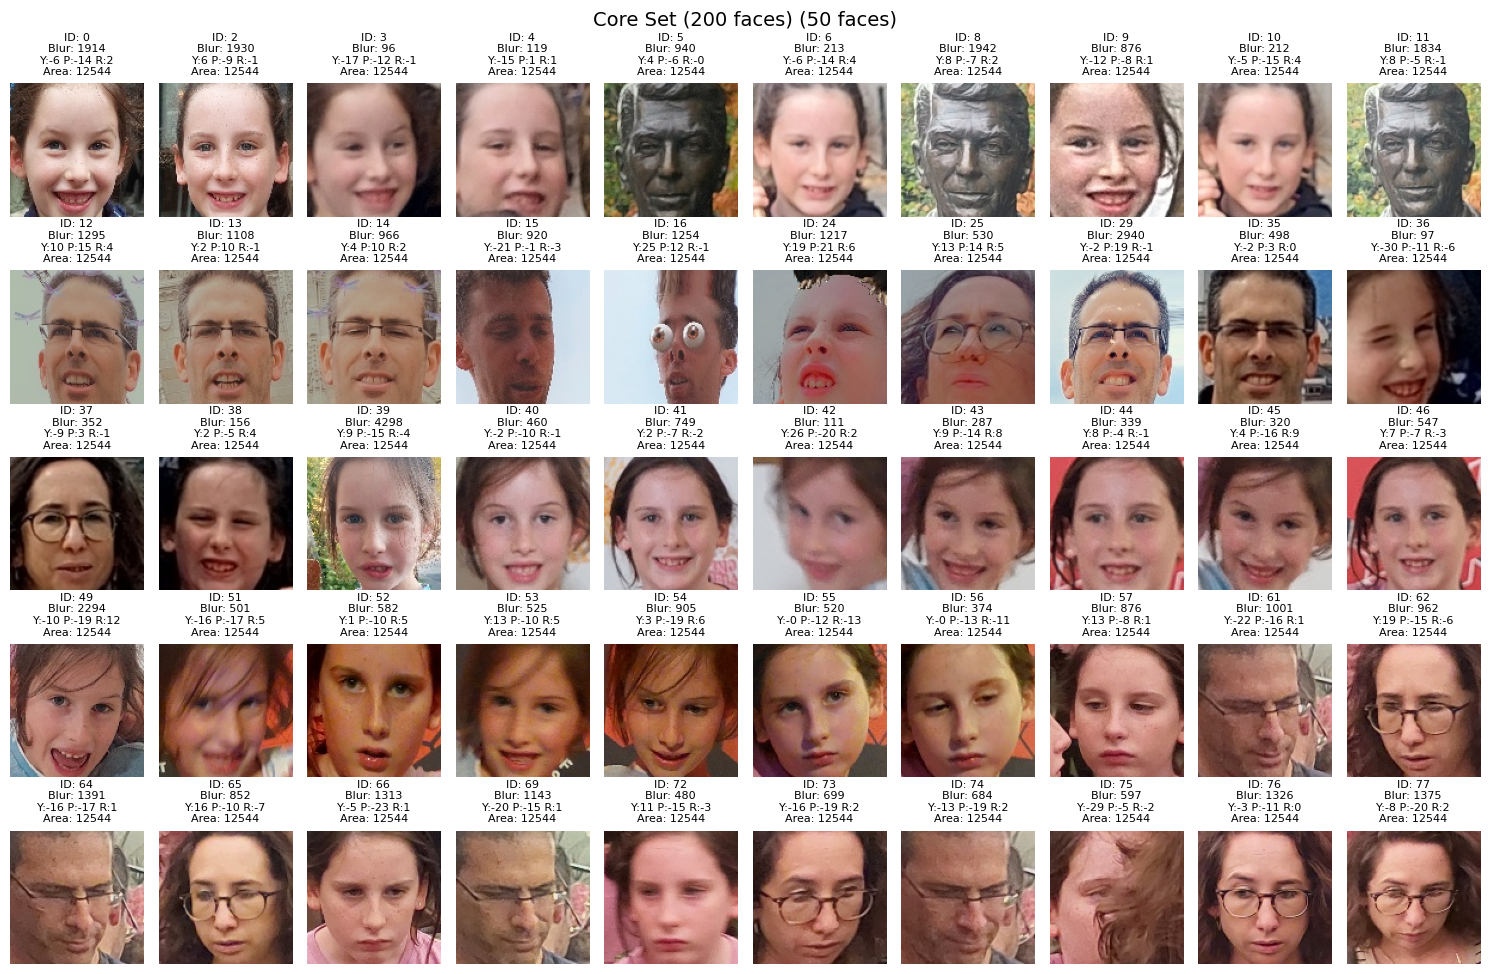

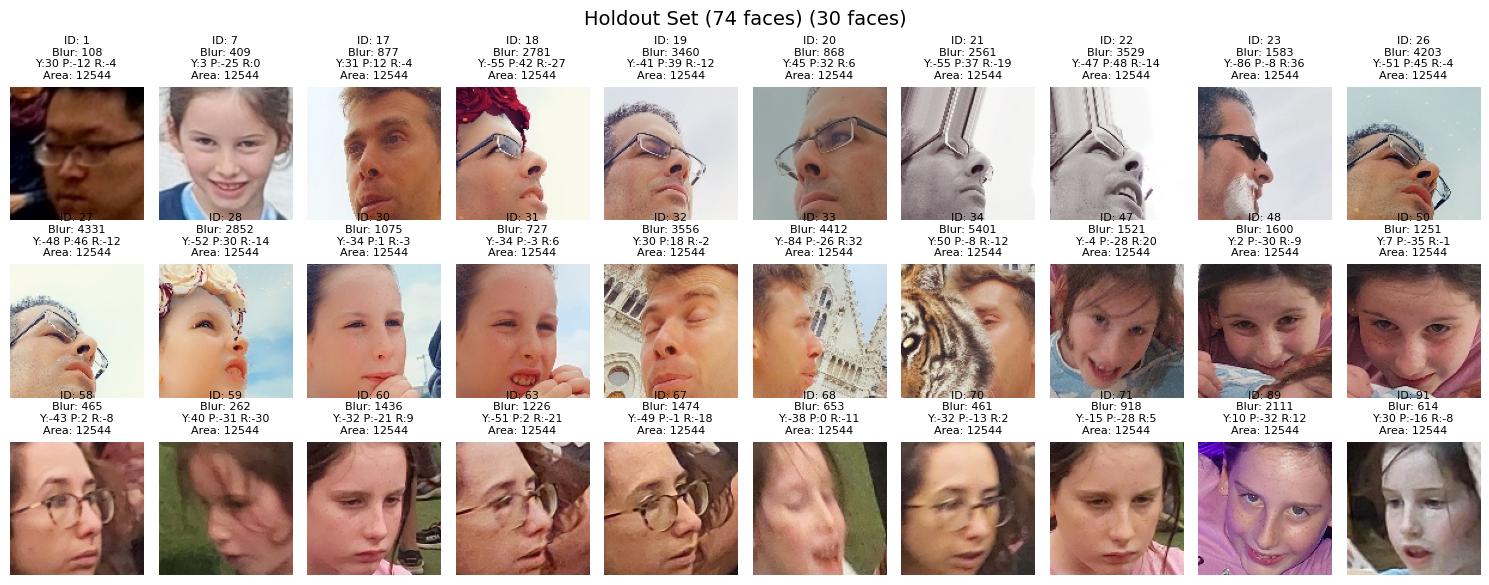

In [ ]:
# Initialize quality gater
gater = QualityGater(
    config,
    use_pose_estimation=ESTIMATE_POSE_FROM_CROPS if USE_EXISTING_EMBEDDINGS else False,
    device='cpu'
)

if USE_EXISTING_EMBEDDINGS:
    # Compute blur scores from aligned face crops
    print("Applying quality gating...")
    faces = gater.compute_blur_scores(faces)
    
    # Optionally compute pose from face crops
    if ESTIMATE_POSE_FROM_CROPS:
        print("Computing pose from face crops (this may take a while)...")
        faces = gater.compute_pose_scores(faces)
        poses_computed = sum(1 for f in faces if f.pose is not None and f.pose != (0.0, 0.0, 0.0))
        print(f"  Pose computed for {poses_computed}/{len(faces)} faces")
    
    # Filter by blur + pose (if available)
    core_indices = []
    holdout_indices = []
    
    for i, face in enumerate(faces):
        passes_blur = face.blur_score >= config.blur_min
        passes_pose = True
        
        if ESTIMATE_POSE_FROM_CROPS and face.pose is not None:
            yaw, pitch, roll = face.pose
            passes_pose = (
                abs(yaw) <= config.yaw_max and
                abs(pitch) <= config.pitch_max and
                abs(roll) <= config.roll_max
            )
        
        if passes_blur and passes_pose:
            core_indices.append(i)
            face.is_core = True
        else:
            holdout_indices.append(i)
            face.is_core = False
    
    print(f"\nQuality gating results:")
    print(f"  Core set: {len(core_indices)} faces")
    print(f"  Holdout set: {len(holdout_indices)} faces")
    
    # Show quality distribution
    blur_scores = [f.blur_score for f in faces]
    print(f"\nBlur score distribution:")
    print(f"  Min: {min(blur_scores):.1f}, Median: {np.median(blur_scores):.1f}, Max: {max(blur_scores):.1f}")
    print(f"  Threshold: {config.blur_min:.1f}")
    
    if ESTIMATE_POSE_FROM_CROPS:
        yaws = [abs(f.pose[0]) for f in faces if f.pose is not None]
        pitches = [abs(f.pose[1]) for f in faces if f.pose is not None]
        rolls = [abs(f.pose[2]) for f in faces if f.pose is not None]
        if len(yaws) > 0:
            print(f"\nPose distribution (absolute values):")
            print(f"  Yaw:   min={min(yaws):.1f}, median={np.median(yaws):.1f}, max={max(yaws):.1f} (threshold={config.yaw_max:.1f})")
            print(f"  Pitch: min={min(pitches):.1f}, median={np.median(pitches):.1f}, max={max(pitches):.1f} (threshold={config.pitch_max:.1f})")
            print(f"  Roll:  min={min(rolls):.1f}, median={np.median(rolls):.1f}, max={max(rolls):.1f} (threshold={config.roll_max:.1f})")
    
else:
    # Full quality gating (blur + pose + per-image filtering)
    print("Applying full quality gating (blur + pose + per-image filtering)...")
    
    # Compute blur scores
    faces = gater.compute_blur_scores(faces)
    
    # Select core and holdout sets (uses all criteria)
    core_indices, holdout_indices = gater.select_core_set(faces)
    
    print(f"\nQuality gating results:")
    print(f"  Core set: {len(core_indices)} faces")
    print(f"  Holdout set: {len(holdout_indices)} faces")
    
    # Show quality statistics
    print("\nCore faces quality (sample):")
    for i in core_indices[:5]:
        face = faces[i]
        pose_str = f"Y:{face.pose[0]:.0f} P:{face.pose[1]:.0f} R:{face.pose[2]:.0f}" if face.pose else "N/A"
        print(f"  Face {face.face_id}: blur={face.blur_score:.0f}, pose=({pose_str}), area={face.area:.0f}")

# Visualize core set
show_face_grid(faces, core_indices[:50], title=f"Core Set ({len(core_indices)} faces)", max_faces=50)
if len(holdout_indices) > 0:
    show_face_grid(faces, holdout_indices[:30], title=f"Holdout Set ({len(holdout_indices)} faces)", max_faces=30)

## Manual Intervention: Override Core Set

**Optional**: Manually adjust which faces are in core vs holdout.

In [ ]:
# # Uncomment to manually override core set
# forced_core_ids = []  # e.g., [0, 5, 10] - face IDs to force into core
# excluded_face_ids = []  # e.g., [3, 7] - face IDs to force into holdout

# # Apply overrides
# for face_id in forced_core_ids:
#     idx = next(i for i, f in enumerate(faces) if f.face_id == face_id)
#     if idx not in core_indices:
#         core_indices.append(idx)
#     if idx in holdout_indices:
#         holdout_indices.remove(idx)
#     faces[idx].is_core = True

# for face_id in excluded_face_ids:
#     idx = next(i for i, f in enumerate(faces) if f.face_id == face_id)
#     if idx in core_indices:
#         core_indices.remove(idx)
#     if idx not in holdout_indices:
#         holdout_indices.append(idx)
#     faces[idx].is_core = False

# print(f"After override: core={len(core_indices)}, holdout={len(holdout_indices)}")

## Stage B: Compute Distance Matrix

Compute pairwise cosine distance matrix for **core faces**.

Building distance matrix...
Distance matrix shape: (200, 200)
  Min: 0.000
  Max: 1.167
  Mean: 0.785
  Median: 0.839

Found top-5 neighbors for each face

Top-K Nearest Neighbors (showing first 10 samples):

Sample   Neighbors                                Distances                               
------------------------------------------------------------------------------------------
0          2,  80,  78,  77, 140                  0.212, 0.293, 0.334, 0.353, 0.357       
1        175,   5,  24,   8,   3                  0.170, 0.186, 0.208, 0.228, 0.256       
2          0,  80, 182,   7,  55                  0.212, 0.272, 0.308, 0.341, 0.347       
3          8,   5,   1,  60,  21                  0.218, 0.228, 0.256, 0.325, 0.334       
4          9,   6,  20, 160, 180                  0.083, 0.092, 0.814, 0.823, 0.827       
5          8,   1, 175,   3,  24                  0.058, 0.186, 0.223, 0.228, 0.257       
6          9,   4,  20, 153, 180                  0.055, 0.092,

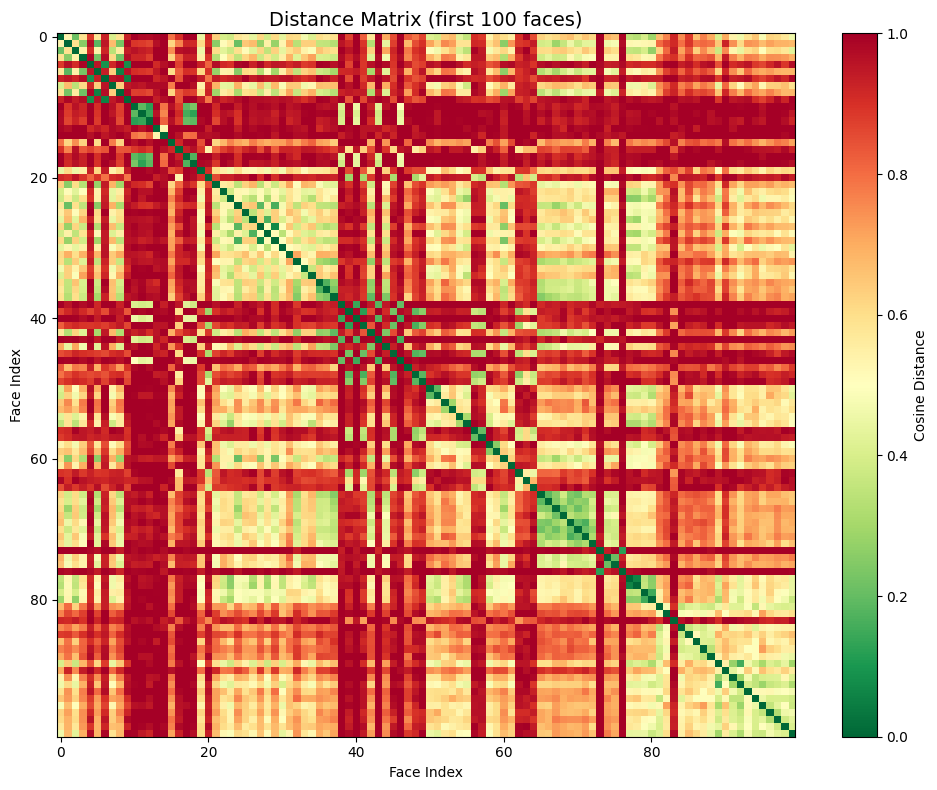

In [ ]:
# Initialize graph builder
graph_builder = KNNGraphBuilder(config)

# Compute distance matrix
print("Building distance matrix...")
distance_matrix = graph_builder.build_distance_matrix(faces, core_indices)

print(f"Distance matrix shape: {distance_matrix.shape}")
print(f"  Min: {distance_matrix.min():.3f}")
print(f"  Max: {distance_matrix.max():.3f}")
print(f"  Mean: {distance_matrix.mean():.3f}")
print(f"  Median: {np.median(distance_matrix):.3f}")

# Find kNN neighbors
neighbors, neighbor_distances = graph_builder.find_knn(distance_matrix, config.K)

print(f"\nFound top-{config.K} neighbors for each face")

# Show kNN table
plot_knn_table(neighbors, neighbor_distances, max_samples=10)

# Visualize distance matrix (sample for large datasets)
if len(core_indices) <= 100:
    plot_distance_matrix(distance_matrix, labels=None, title="Core Faces Distance Matrix")
else:
    print(f"\nDataset too large ({len(core_indices)} faces) - showing first 100")
    plot_distance_matrix(distance_matrix[:100, :100], labels=None, title="Distance Matrix (first 100 faces)")

## Stage C: Build Mutual kNN Graph

In [ ]:
# Build mutual kNN graph
graph_result = graph_builder.build_mutual_knn_graph(
    distance_matrix,
    config.K,
    config.distance_threshold
)

print(f"Mutual kNN graph:")
print(f"  Nodes: {graph_result.G.number_of_nodes()}")
print(f"  Edges: {graph_result.G.number_of_edges()}")
if len(core_indices) > 1:
    print(f"  Edge density: {graph_result.G.number_of_edges() / (len(core_indices) * (len(core_indices) - 1) / 2):.2%}")

# Show edge list (sample)
print(f"\nEdges (showing first 20):")
for i, (u, v, dist) in enumerate(graph_result.edges[:20]):
    face_u = faces[core_indices[u]]
    face_v = faces[core_indices[v]]
    print(f"  Edge {i}: ({face_u.face_id}, {face_v.face_id}) dist={dist:.3f}")

INFO: Built mutual kNN graph: 200 nodes, 194 edges (k=5, threshold=0.350)


Mutual kNN graph:
  Nodes: 200
  Edges: 194
  Edge density: 0.97%

Edges (showing first 20):
  Edge 0: (0, 3) dist=0.212
  Edge 1: (2, 249) dist=0.170
  Edge 2: (2, 6) dist=0.186
  Edge 3: (2, 41) dist=0.208
  Edge 4: (2, 10) dist=0.228
  Edge 5: (2, 4) dist=0.256
  Edge 6: (3, 113) dist=0.272
  Edge 7: (3, 256) dist=0.308
  Edge 8: (3, 9) dist=0.341
  Edge 9: (4, 10) dist=0.218
  Edge 10: (4, 6) dist=0.228
  Edge 11: (5, 11) dist=0.083
  Edge 12: (5, 8) dist=0.092
  Edge 13: (6, 10) dist=0.058
  Edge 14: (8, 11) dist=0.055
  Edge 15: (12, 14) dist=0.121
  Edge 16: (12, 29) dist=0.188
  Edge 17: (12, 13) dist=0.190
  Edge 18: (12, 35) dist=0.234
  Edge 19: (12, 258) dist=0.307


## Manual Intervention: Edit Edge List

**Optional**: Remove suspicious edges before clustering.

In [ ]:
# # Uncomment to manually remove edges
# edges_to_remove = []  # e.g., [(0, 5), (3, 7)] - node indices (not face IDs)

# import networkx as nx
# for u, v in edges_to_remove:
#     if graph_result.G.has_edge(u, v):
#         graph_result.G.remove_edge(u, v)
#         print(f"Removed edge: ({u}, {v})")

# # Update edge list
# graph_result.edges = [(u, v, graph_result.distance_matrix[u, v]) 
#                       for u, v in graph_result.G.edges()]

# print(f"After manual edit: {graph_result.G.number_of_edges()} edges")

## Stage D: Connected Components Clustering

INFO: Clustering: 26 clusters, 66 noise points (min_cluster_size=2)


Clustering complete:
  Clusters: 26
  Noise points: 66

CLUSTER SNAPSHOT: initial_clustering

Faces:
  Total: 274
  Core: 200
  Holdout: 74

Clusters:
  Count: 26
  Noise: 66
  Size range: 2 - 17 faces
  Mean size: 5.2
  Median size: 3.5

Cluster diameters:
  Min: 0.092
  Median: 0.332
  Max: 0.561



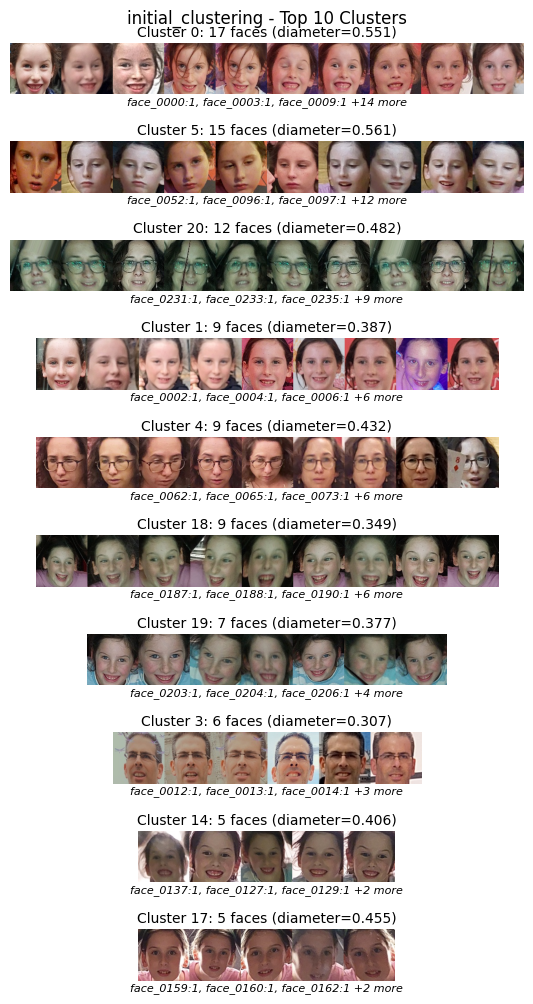


Dataset too large - showing first 100 nodes


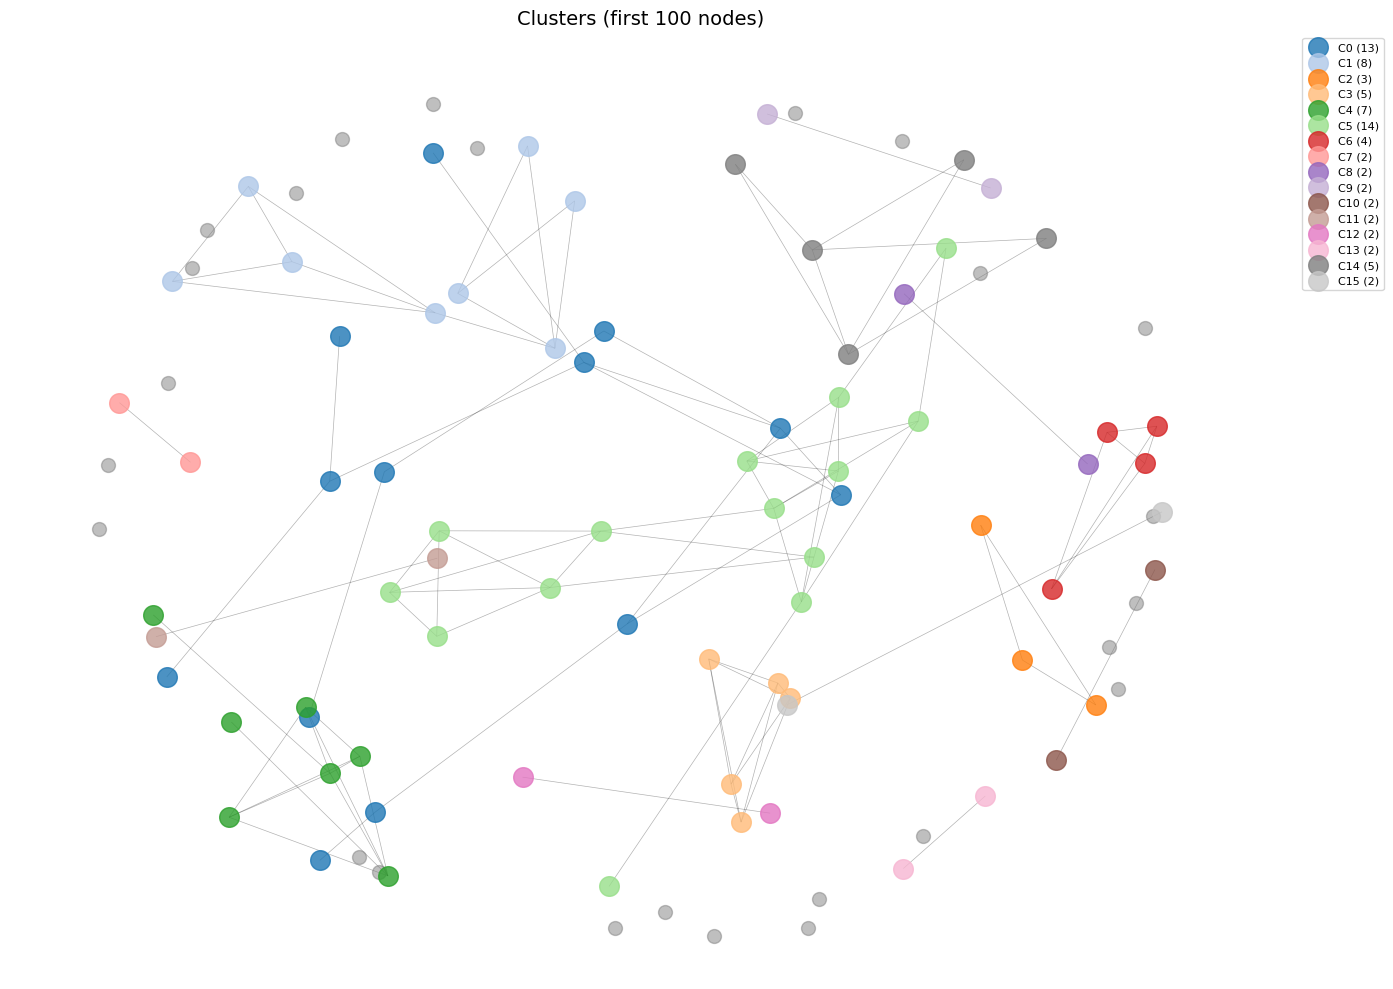

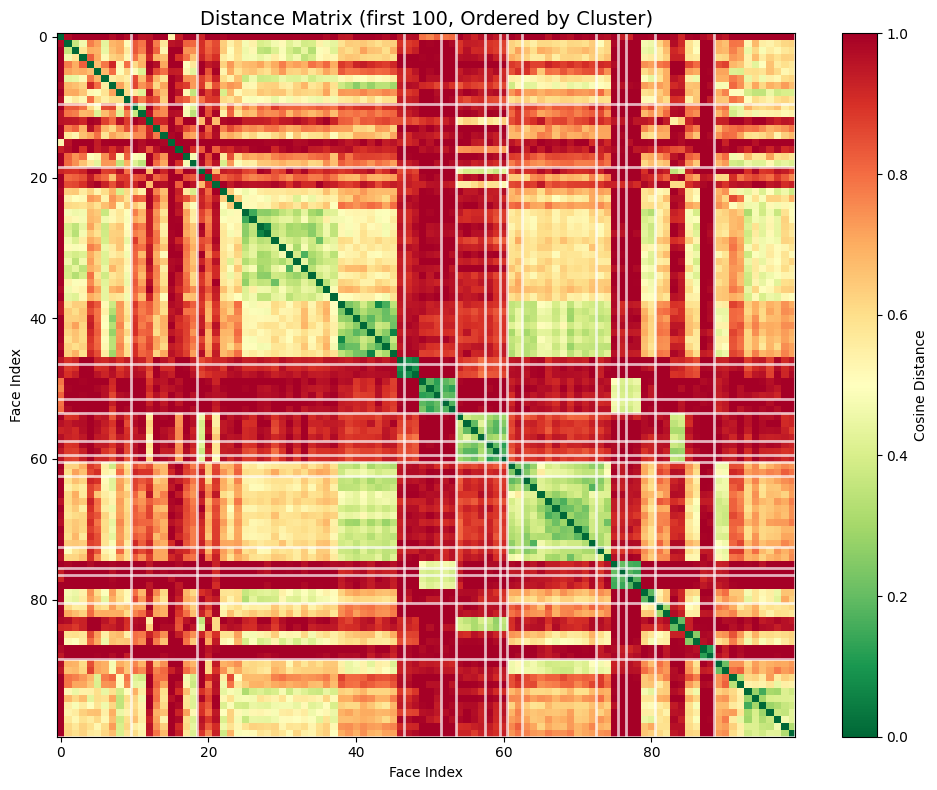

In [ ]:
# Initialize clusterer
clusterer = ConnectedComponentsClusterer(config)

# Run clustering
cluster_result = clusterer.cluster(graph_result, core_indices)

print(f"Clustering complete:")
print(f"  Clusters: {cluster_result.n_clusters}")
print(f"  Noise points: {cluster_result.n_noise}")

# Create ClusterSnapshot for analysis
snapshot_initial = ClusterSnapshot.from_result(
    cluster_result,
    faces,
    core_indices,
    distance_matrix,
    stage="initial_clustering",
    config=config
)

# Print summary
snapshot_initial.print_summary()

# Visualize using snapshot
snapshot_initial.plot_overview(max_clusters=10, max_faces_per_cluster=20)

# Visualize graph with cluster colors (sample for large datasets)
if len(core_indices) <= 100:
    plot_graph(graph_result, cluster_result.labels, title="Clusters (Connected Components)")
else:
    print(f"\nDataset too large - showing first 100 nodes")
    import networkx as nx
    from face_cluster.types import GraphResult
    G_sample = graph_result.G.subgraph(range(min(100, len(core_indices))))
    graph_sample = GraphResult(
        neighbors=graph_result.neighbors[:100],
        neighbor_distances=graph_result.neighbor_distances[:100],
        edges=[(u, v, d) for u, v, d in graph_result.edges if u < 100 and v < 100],
        G=G_sample,
        distance_matrix=graph_result.distance_matrix[:100, :100]
    )
    plot_graph(graph_sample, cluster_result.labels[:100], title="Clusters (first 100 nodes)")

# Show distance matrix ordered by cluster (sample)
if len(core_indices) <= 100:
    plot_distance_matrix(
        distance_matrix, 
        labels=cluster_result.labels, 
        title="Distance Matrix (Ordered by Cluster)"
    )
else:
    plot_distance_matrix(
        distance_matrix[:100, :100],
        labels=cluster_result.labels[:100],
        title="Distance Matrix (first 100, Ordered by Cluster)"
    )

## Stage E: Exemplar Selection (d10 Metric)

INFO: Cluster 0: 9 exemplars from 17 faces
INFO: Cluster 1: 5 exemplars from 9 faces
INFO: Cluster 2: 1 exemplars from 3 faces
INFO: Cluster 3: 2 exemplars from 6 faces
INFO: Cluster 4: 4 exemplars from 9 faces
INFO: Cluster 5: 10 exemplars from 15 faces
INFO: Cluster 6: 1 exemplars from 4 faces
INFO: Cluster 7: 1 exemplars from 2 faces
INFO: Cluster 8: 2 exemplars from 2 faces
INFO: Cluster 9: 2 exemplars from 2 faces
INFO: Cluster 10: 2 exemplars from 2 faces
INFO: Cluster 11: 1 exemplars from 2 faces
INFO: Cluster 12: 2 exemplars from 2 faces
INFO: Cluster 13: 2 exemplars from 2 faces
INFO: Cluster 14: 1 exemplars from 5 faces
INFO: Cluster 15: 2 exemplars from 2 faces
INFO: Cluster 16: 1 exemplars from 4 faces
INFO: Cluster 17: 4 exemplars from 5 faces
INFO: Cluster 18: 3 exemplars from 9 faces
INFO: Cluster 19: 4 exemplars from 7 faces
INFO: Cluster 20: 5 exemplars from 12 faces
INFO: Cluster 21: 2 exemplars from 2 faces
INFO: Cluster 22: 2 exemplars from 2 faces
INFO: Cluster 23:

Exemplar selection complete (showing first 10 clusters)
  Cluster 0: 9 exemplars (IDs: [110, 250, 40, 113, 83, 3, 45, 256, 0])
  Cluster 1: 5 exemplars (IDs: [46, 2, 10, 88, 4])
  Cluster 2: 1 exemplars (IDs: [11])
  Cluster 3: 2 exemplars (IDs: [13, 258])
  Cluster 4: 4 exemplars (IDs: [76, 254, 37, 92])
  Cluster 5: 10 exemplars (IDs: [102, 100, 57, 96, 98, 55, 52, 99, 104, 72])
  Cluster 6: 1 exemplars (IDs: [64])
  Cluster 7: 1 exemplars (IDs: [78])
  Cluster 8: 2 exemplars (IDs: [80, 81])
  Cluster 9: 2 exemplars (IDs: [84, 85])


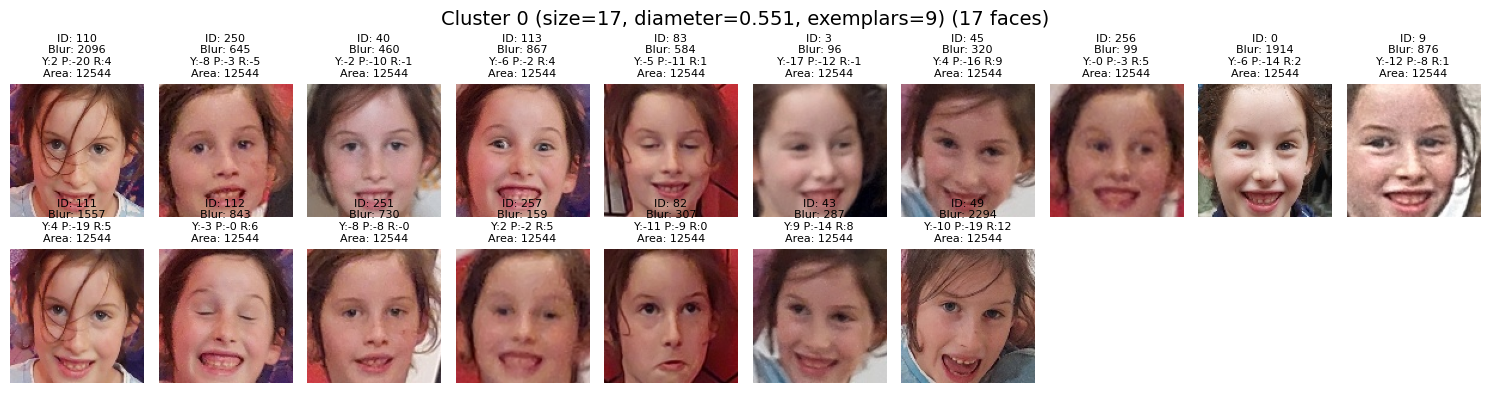

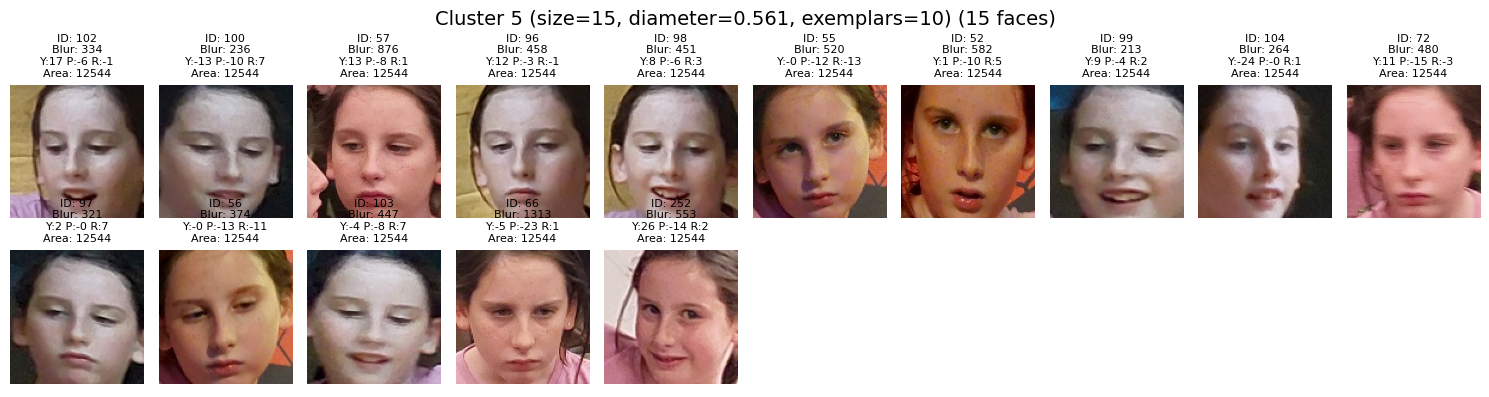

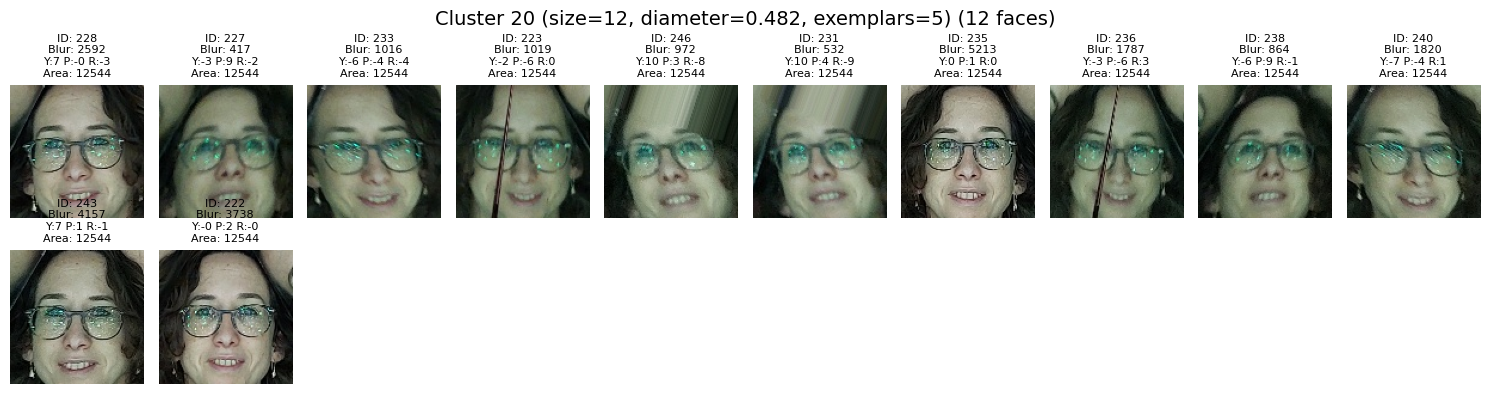

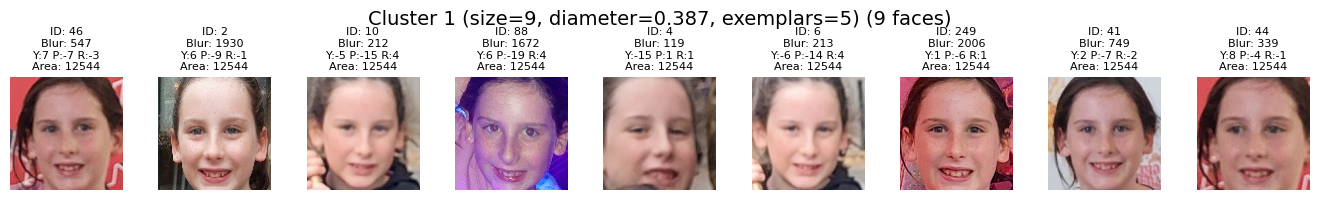

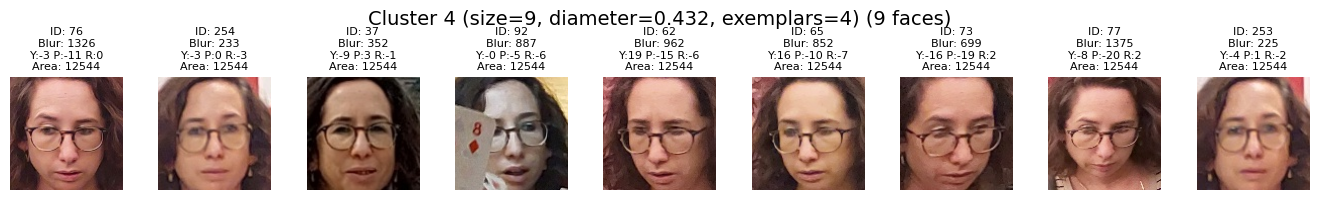

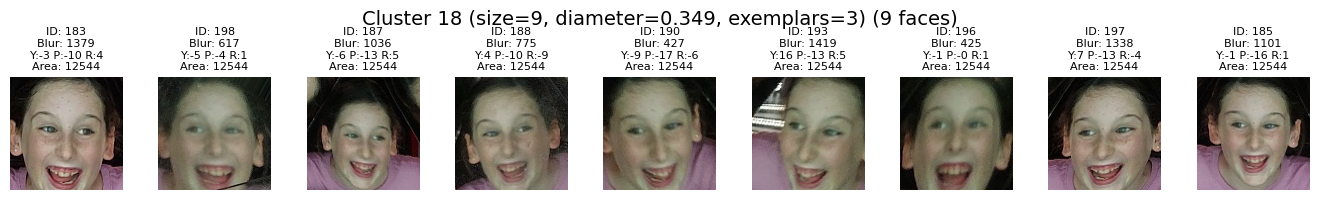

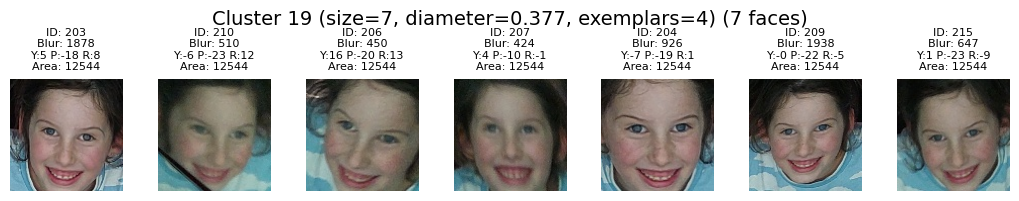

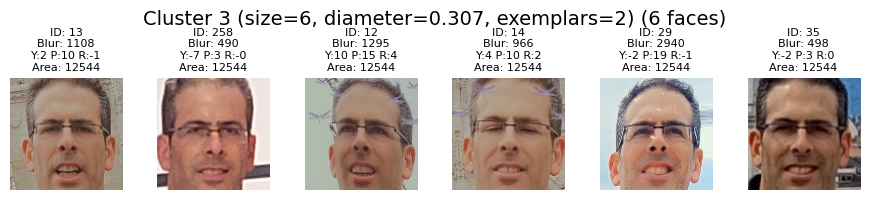

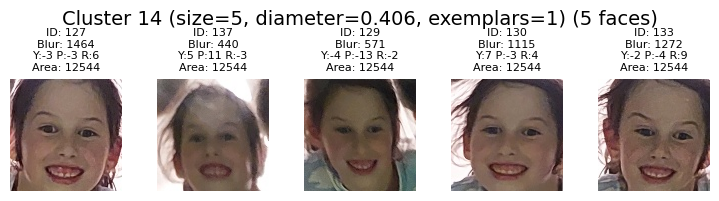

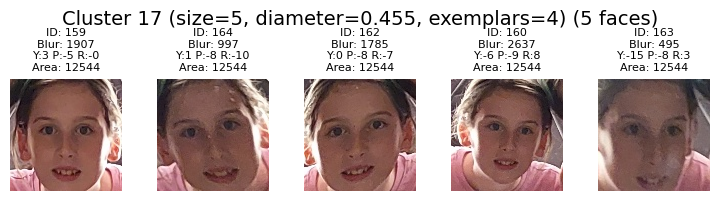

In [ ]:
# Initialize exemplar selector
exemplar_selector = D10ExemplarSelector(config)

# Select exemplars
cluster_result = exemplar_selector.select_exemplars(cluster_result, graph_result)

print(f"Exemplar selection complete (showing first 10 clusters)")
for cluster_id, exemplar_nodes in sorted(cluster_result.exemplars.items())[:10]:
    exemplar_face_ids = [faces[core_indices[n]].face_id for n in exemplar_nodes]
    print(f"  Cluster {cluster_id}: {len(exemplar_nodes)} exemplars (IDs: {exemplar_face_ids})")

# Show faces for each cluster (exemplars highlighted)
show_cluster_faces(
    [faces[i] for i in core_indices],  # Map to core subset
    cluster_result,
    max_clusters=10,
    max_faces_per_cluster=20,
    highlight_exemplars=True
)

## Exemplar Analysis: d10 Distribution

Cluster 0 d10 statistics:
  Min: 0.259
  Median: 0.309
  Max: 0.403
  Exemplar threshold: 0.350
  Faces below threshold: 13 / 17


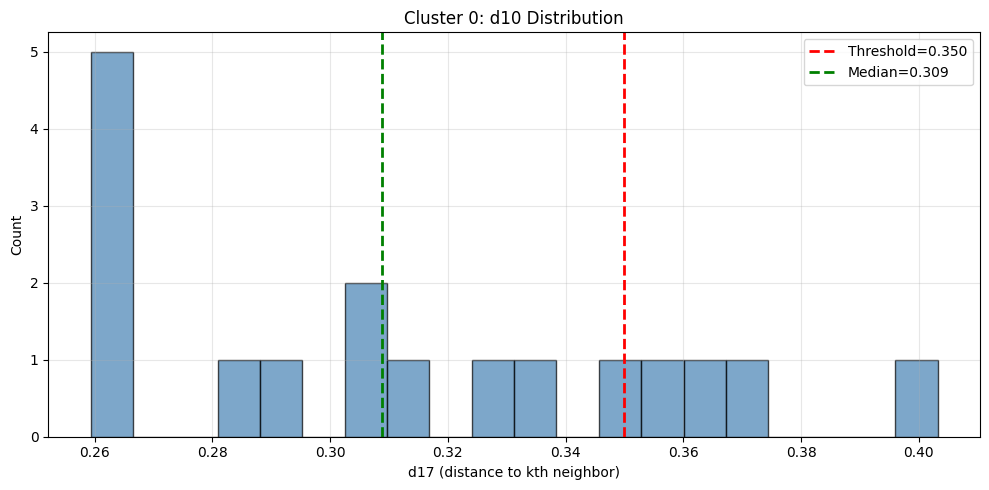


WIDEST CLUSTERS ANALYSIS

Top 3 widest clusters:
  Cluster 5: diameter=0.561, size=15
    From 15 images: ['face_0052', 'face_0096', 'face_0097', 'face_0055', 'face_0056']
  Cluster 0: diameter=0.551, size=17
    From 17 images: ['face_0000', 'face_0003', 'face_0009', 'face_0110', 'face_0111']
  Cluster 20: diameter=0.482, size=12
    From 12 images: ['face_0231', 'face_0233', 'face_0235', 'face_0236', 'face_0238']


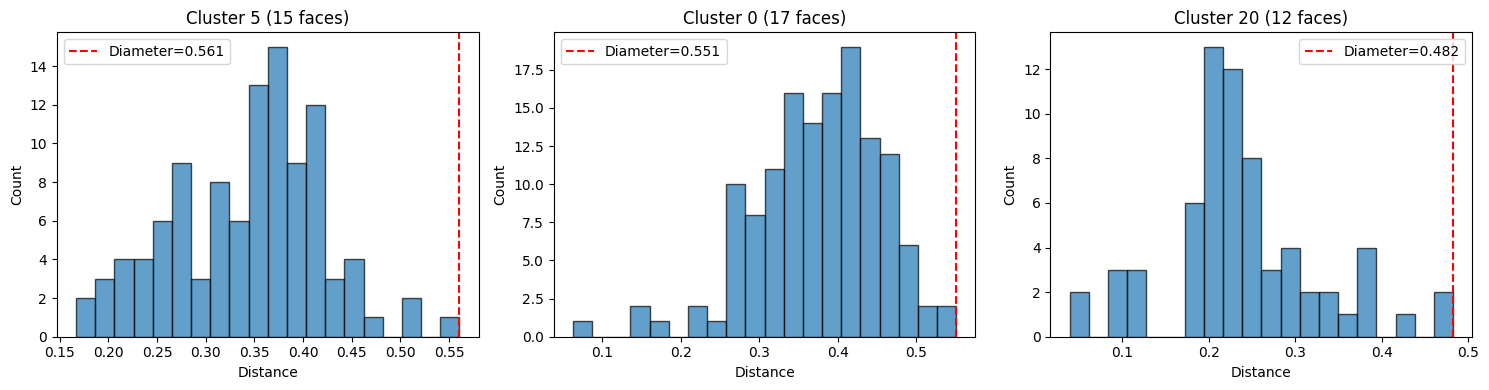

In [ ]:
# Choose a cluster to analyze
CLUSTER_ID_TO_ANALYZE = 0  # Change this to analyze different clusters

if CLUSTER_ID_TO_ANALYZE in cluster_result.clusters:
    cluster_nodes = cluster_result.clusters[CLUSTER_ID_TO_ANALYZE]
    
    # Compute d10 values
    d10_values = exemplar_selector.get_d10_values(
        cluster_nodes,
        distance_matrix
    )
    
    print(f"Cluster {CLUSTER_ID_TO_ANALYZE} d10 statistics:")
    print(f"  Min: {d10_values.min():.3f}")
    print(f"  Median: {np.median(d10_values):.3f}")
    print(f"  Max: {d10_values.max():.3f}")
    print(f"  Exemplar threshold: {config.exemplars_d10_threshold:.3f}")
    print(f"  Faces below threshold: {(d10_values <= config.exemplars_d10_threshold).sum()} / {len(d10_values)}")
    
    # Plot histogram
    plot_d10_histogram(d10_values, config.exemplars_d10_threshold, CLUSTER_ID_TO_ANALYZE)
else:
    print(f"Cluster {CLUSTER_ID_TO_ANALYZE} not found")

# Analyze widest clusters (quality check)
print("\n" + "="*60)
print("WIDEST CLUSTERS ANALYSIS")
print("="*60)
snapshot_initial.plot_widest_clusters(top_k=3, show_histogram=True)

## Stage F2 (Optional): Conservative Merge

Merge over-fragmented clusters using **multi-evidence approach**:

### Merge Criteria (ALL must pass):
1. **Exemplar Distance**: `min(exemplar_dist) ≤ T_merge`
2. **Support Count**: Sufficient cross-cluster pairs below threshold
3. **Margin**: Best cluster clearly better than 2nd best (avoid ambiguous merges)
4. **Diameter**: Post-merge diameter ≤ max_allowed (don't create wide clusters)

### Adaptive Threshold Formula:
```
T_merge = α × MAX(T_A, T_B) + (1-α) × T_global

where:
  T_i = P90(exemplar pairwise distances within cluster i)
  T_global = median(T_1, T_2, ..., T_n) across all clusters
  α = merge_threshold_alpha (default 0.7)
```

**Why MAX?** Allows merging across different density regions (looser cluster can merge with tighter one).

**Output DataFrame Columns:**
- `Exemplar_Dist`: Min distance between cluster exemplars
- `T_A, T_B`: Per-cluster thresholds (P90 of intra-cluster exemplar distances)
- `T_local`: MAX(T_A, T_B)
- `T_global`: Median threshold across all clusters
- `T_merge`: Final hybrid threshold = 0.7×T_local + 0.3×T_global
- `Gap`: Exemplar_Dist - T_merge (negative means would merge if only exemplar criterion mattered)
- `Failed`: Which criteria failed (Exemplar, Support, Margin, Diameter)

**Note**: Only runs if `merge_enabled=True` in config.

INFO: Adaptive thresholds: global=0.351, local range=[0.090, 0.432]
INFO: Iteration 1: Merged clusters 1 and 18 (25 clusters remaining)
INFO: Iteration 2: Merged clusters 4 and 9 (24 clusters remaining)
INFO: Iteration 3: Merged clusters 0 and 19 (23 clusters remaining)
INFO: Iteration 4: Merged clusters 1 and 5 (22 clusters remaining)
INFO: Iteration 5: Merged clusters 4 and 20 (21 clusters remaining)
INFO: Iteration 6: Merged clusters 1 and 25 (20 clusters remaining)
INFO: Iteration 7: Merged clusters 0 and 14 (19 clusters remaining)
INFO: Iteration 8: Merged clusters 1 and 17 (18 clusters remaining)
INFO: Iteration 9: Merged clusters 0 and 16 (17 clusters remaining)
INFO: Iteration 10: Merged clusters 0 and 7 (16 clusters remaining)
INFO: Iteration 11: Merged clusters 0 and 10 (15 clusters remaining)
INFO: Iteration 12: Merged clusters 1 and 12 (14 clusters remaining)
INFO: Iteration 13: Merged clusters 0 and 15 (13 clusters remaining)
INFO: Iteration 14: Merged clusters 4 and 22 (1

Conservative merge enabled...
  Initial clusters: 26

After merging:
  Clusters: 11
  Merged: 15 clusters

CLUSTER SNAPSHOT: after_merge

Faces:
  Total: 274
  Core: 200
  Holdout: 74

Clusters:
  Count: 11
  Noise: 66
  Size range: 2 - 44 faces
  Mean size: 12.2
  Median size: 3.0

Cluster diameters:
  Min: 0.092
  Median: 0.307
  Max: 0.807

Exemplars:
  Total: 42
  Per cluster: 3.8 avg



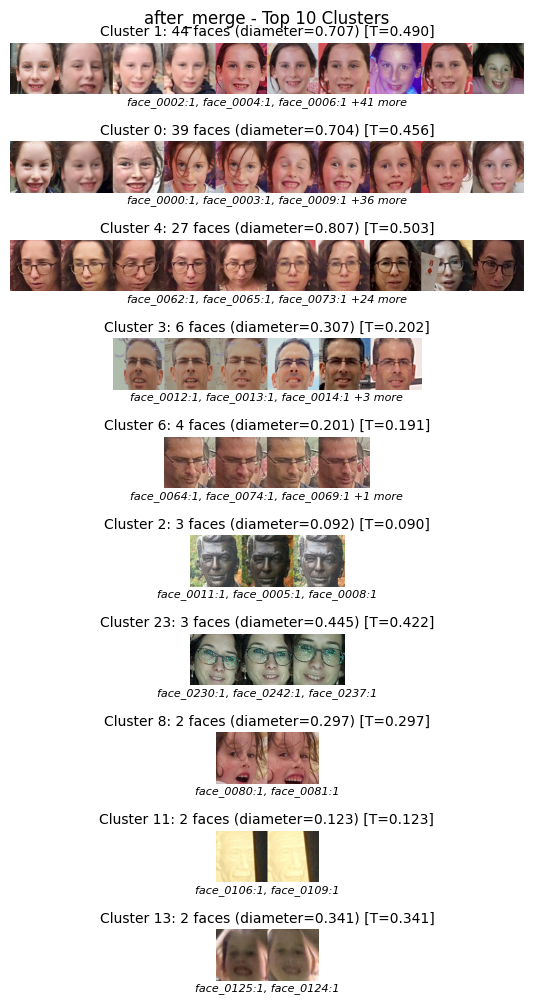


Merge Decisions:
 C1  C2  Size1  Size2  Exemplar_Dist   T_A   T_B  T_local  T_global  T_merge  Gap  Merged                      Failed
  3   6      6      4          0.413 0.202 0.191    0.202     0.439    0.273 0.14   False Exemplar, Support, Diameter


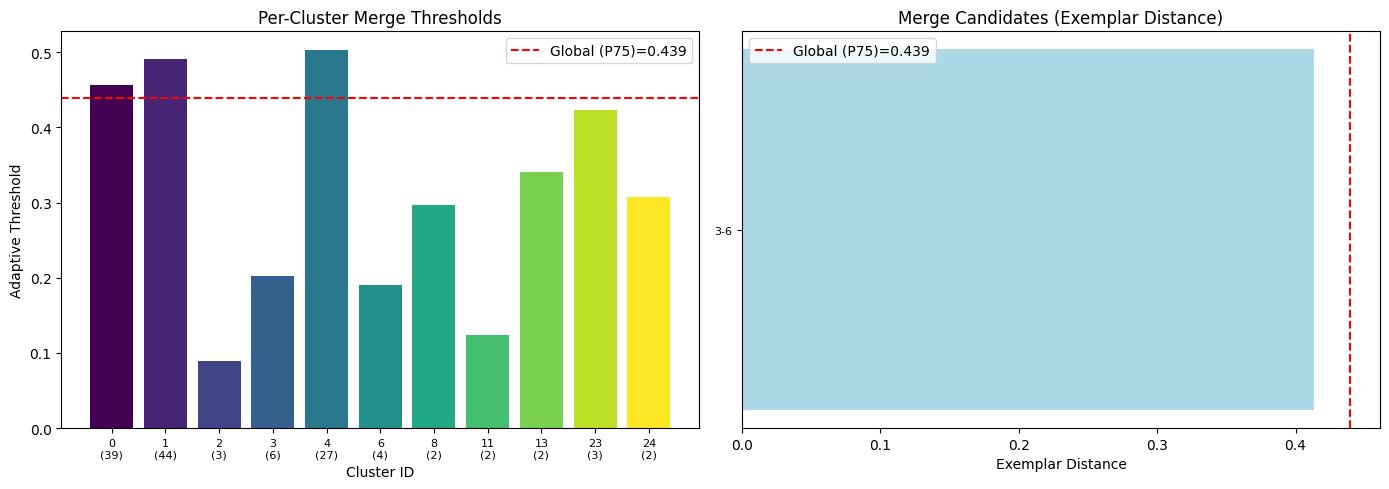


Closest Cluster Pairs:
 C1  C2  Size1  Size2  Min_Dist  T_merge    Gap
  4  23     27      3     0.278    0.484 -0.206
  3   6      6      4     0.379    0.273  0.106
  0   1     39     44     0.440    0.475 -0.035
  0  13     39      2     0.446    0.451 -0.004
  0   8     39      2     0.506    0.451  0.055

COMPARISON: after_merge vs initial_clustering

Clusters:
  after_merge: 11 clusters, 66 noise
  initial_clustering: 26 clusters, 66 noise
  Change: +15 clusters, +0 noise

Cluster size distribution:
  after_merge: [44, 39, 27, 6, 4, 3, 3, 2, 2, 2]
  initial_clustering: [17, 15, 12, 9, 9, 9, 7, 6, 5, 5]



In [ ]:
if config.merge_enabled:
    print(f"Conservative merge enabled...")
    print(f"  Initial clusters: {cluster_result.n_clusters}")
    
    # Initialize merger
    merger = ConservativeMerger(config)
    
    # Run merging
    cluster_result_merged = merger.merge_clusters(cluster_result, graph_result)
    
    print(f"\nAfter merging:")
    print(f"  Clusters: {cluster_result_merged.n_clusters}")
    print(f"  Merged: {cluster_result.n_clusters - cluster_result_merged.n_clusters} clusters")
    
    # Create snapshot with decision metadata
    snapshot_merged = ClusterSnapshot.from_result(
        cluster_result_merged,
        faces,
        core_indices,
        distance_matrix,
        stage="after_merge",
        config=config,
        cluster_thresholds=merger.last_thresholds,
        merge_candidates=merger.last_candidates
    )
    
    # Print summary
    snapshot_merged.print_summary()
    
    # Visualize
    snapshot_merged.plot_overview(max_clusters=10, max_faces_per_cluster=20)
    
    # Show decision boundaries
    snapshot_merged.plot_decision_boundaries()
    
    # Show close clusters (sensitivity analysis)
    snapshot_merged.plot_close_clusters(top_k=5)
    
    # Compare before/after
    snapshot_merged.compare_with(snapshot_initial)
    
    # Update result
    cluster_result = cluster_result_merged
    
else:
    print("Conservative merge disabled in config.")

In [ ]:
# Export cluster assignments to CSV for comparison with export script
import pandas as pd

# Build face-to-cluster mapping
face_to_cluster = {}
for cid, cluster_nodes in cluster_result_merged.clusters.items():
    for node_idx in cluster_nodes:
        face_idx = core_indices[node_idx]
        face_to_cluster[face_idx] = cid

# Create DataFrame
notebook_faces = []
for i, face in enumerate(faces):
    cluster_id = face_to_cluster.get(i, -1)
    notebook_faces.append({
        'face_id': face.face_id,
        'cluster_id': cluster_id,
        'is_core': face.is_core
    })

notebook_df = pd.DataFrame(notebook_faces)

# Save to CSV
output_csv = RESULTS_DIR / "notebook_clustering_results.csv"
notebook_df.to_csv(output_csv, index=False)

print(f"Exported notebook clustering to: {output_csv}")
print(f"\nCluster distribution:")
print(notebook_df['cluster_id'].value_counts().sort_index())

Exported notebook clustering to: ..\results\face_clustering_benchmark\notebook_clustering_results.csv

Cluster distribution:
cluster_id
-1     140
 0      39
 1      44
 2       3
 3       6
 4      27
 6       4
 8       2
 11      2
 13      2
 23      3
 24      2
Name: count, dtype: int64


## Final Results Summary

In [ ]:
print("\n" + "="*60)
print("FINAL CLUSTERING RESULTS")
print("="*60)

print(f"\nTotal faces: {len(faces)}")
print(f"  Core: {len(core_indices)}")
print(f"  Holdout: {len(holdout_indices)}")
print(f"\nClusters: {cluster_result.n_clusters}")
print(f"Noise: {cluster_result.n_noise}")

# Show top 10 clusters
sorted_clusters = sorted(
    cluster_result.clusters.items(),
    key=lambda x: len(x[1]),
    reverse=True
)

print(f"\nTop 10 clusters by size:")
for cluster_id, nodes in sorted_clusters[:10]:
    face_ids = [faces[core_indices[n]].face_id for n in nodes]
    print(f"  Cluster {cluster_id}: {len(nodes)} faces")

print(f"\n[SUCCESS] Clustering complete!")


FINAL CLUSTERING RESULTS

Total faces: 274
  Core: 200
  Holdout: 74

Clusters: 11
Noise: 66

Top 10 clusters by size:
  Cluster 1: 44 faces
  Cluster 0: 39 faces
  Cluster 4: 27 faces
  Cluster 3: 6 faces
  Cluster 6: 4 faces
  Cluster 2: 3 faces
  Cluster 23: 3 faces
  Cluster 8: 2 faces
  Cluster 11: 2 faces
  Cluster 13: 2 faces

[SUCCESS] Clustering complete!


In [ ]:
df = snapshot_merged.get_cluster_distances()
print(df.head(20))  # Sorted by Exemplar_Dist                                                                                                                                                                                              
  # Why didn't cluster pair (4, 23) merge?
row = df[(df['C1']==4) & (df['C2']==23)].iloc[0]
row

    C1  C2  Size1  Size2  Exemplar_Dist  Min_Dist  Mean_Dist  Max_Dist
28   3   6      6      4          0.413     0.379      0.433     0.497
0    0   1     39     44          0.453     0.440      0.626     0.851
38   4  23     27      3          0.464     0.278      0.535     0.753
5    0   8     39      2          0.532     0.506      0.617     0.757
7    0  13     39      2          0.538     0.446      0.675     0.841
46   8  13      2      2          0.564     0.564      0.668     0.764
14   1   8     44      2          0.645     0.614      0.749     0.866
16   1  13     44      2          0.726     0.667      0.799     0.915
12   1   4     44     27          0.774     0.736      0.923     1.116
20   2   4      3     27          0.783     0.783      0.872     0.993
3    0   4     39     27          0.818     0.793      0.938     1.091
8    0  23     39      3          0.845     0.814      0.923     1.011
18   1  24     44      2          0.846     0.810      0.914     1.047
47   8

C1                4.000
C2               23.000
Size1            27.000
Size2             3.000
Exemplar_Dist     0.464
Min_Dist          0.278
Mean_Dist         0.535
Max_Dist          0.753
Name: 38, dtype: float64

In [ ]:
close_df = snapshot_merged.get_close_clusters_df()
close_df

,C1,C2,Size1,Size2,Min_Dist,T_merge,Gap
0,4,23,27,3,0.278,0.484,-0.206
1,3,6,6,4,0.379,0.273,0.106
2,0,1,39,44,0.440,0.475,-0.035
3,0,13,39,2,0.446,0.451,-0.004
4,0,8,39,2,0.506,0.451,0.055
5,8,13,2,2,0.564,0.370,0.193
6,1,8,44,2,0.614,0.475,0.139
7,1,13,44,2,0.667,0.475,0.192
8,1,23,44,3,0.705,0.475,0.230
9,1,4,44,27,0.736,0.484,0.252


In [ ]:
get_exemplar_distances(snapshot_merged, 4, 23)

array([[0.513736  ],
       [0.65748155],
       [0.4643392 ],
       [0.4978845 ],
       [0.5496971 ],
       [0.67192996],
       [0.69096255],
       [0.5387848 ],
       [0.6758685 ],
       [0.7288966 ]], dtype=float32)

(<Figure size 500x675 with 2 Axes>,
 <Axes: title={'center': 'Distance Matrix'}, xlabel='Column', ylabel='Row'>)

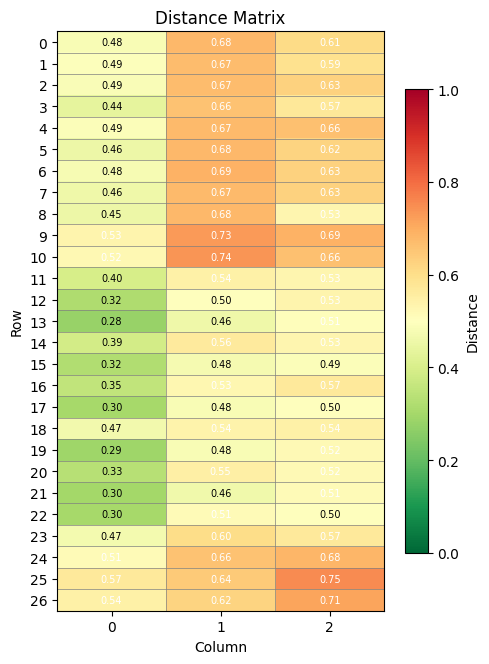

In [ ]:
nodes_a = snapshot_merged.clusters[4]
nodes_b = snapshot_merged.clusters[23]

pairwise = snapshot_merged.distance_matrix[np.ix_(nodes_a, nodes_b)]

plot_distance_matrix_heatmap(pairwise)

## Export Results

In [ ]:
import json
from datetime import datetime

# Prepare results for export
results = {
    'timestamp': datetime.now().isoformat(),
    'data_source': 'existing_embeddings' if USE_EXISTING_EMBEDDINGS else 'new_images',
    'config': {
        'K': config.K,
        'distance_threshold': config.distance_threshold,
        'min_cluster_size': config.min_cluster_size,
    },
    'summary': {
        'n_faces': len(faces),
        'n_core': len(core_indices),
        'n_holdout': len(holdout_indices),
        'n_clusters': cluster_result.n_clusters,
        'n_noise': cluster_result.n_noise,
    },
    'clusters': {},
}

# Add cluster details
for cluster_id, cluster_nodes in cluster_result.clusters.items():
    cluster_face_indices = [core_indices[n] for n in cluster_nodes]
    
    results['clusters'][int(cluster_id)] = {
        'size': len(cluster_face_indices),
        'face_ids': [int(faces[i].face_id) for i in cluster_face_indices],
        'stats': cluster_result.cluster_stats.get(cluster_id, {}),
    }

# Save to JSON
output_path = Path("../results/knn_clustering_results.json")
output_path.parent.mkdir(exist_ok=True)
with open(output_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {output_path}")

Results saved to: ..\results\knn_clustering_results.json
